### Neuronas sin uso de bibliotecas 

In [1]:
import math 
import random

#funcion de activacion sigmoide, es muy utilizada sin embargo, tiene muchas limitantes 
def sigmoid(x):
    return 1 / (1+math.exp(-x))

#neruona simple 
class Neurona: 
    def __init__(self, n_inputs):
        self.weights = [random.random() for _ in range(n_inputs)]
        self.bias = random.random()

    def forward(self, inputs):
        z = sum(w * x for w, x in zip(self.weights, inputs)) + self.bias
        return sigmoid(z)
    
#creando instancia de neurona 
neuron = Neurona(2)

output = neuron.forward([0.5, 0.8])
print("Salida: ", output)

Salida:  0.8143010276870616


### Entrenamiento

In [2]:
def sigmoid_derivation(x):
    return x*(1-x)

class Neuron: 
    def __init__(self, n_inputs):
        self.weights = [random.random() for _ in range(n_inputs)]
        self.bias = random.random()

    #forward
    def forward(self, inputs):
        self.inputs = inputs
        self.z = sum(w*x for w , x in zip(self.weights, inputs))
        self.output = sigmoid(self.z)
        return self.output
    
    #backward
    def backward(self, target, lr):
        error = target - self.output
        d_output = error * sigmoid_derivation(self.output)

        #actualizar los pesos de las neuronas 
        for i in range(len(self.weights)):
            self.weights[i] += lr * d_output * self.inputs[i]
        self.bias += lr*d_output    

#introduccion de datos
data = [
    ([0,0],0),
    ([0,1],1),
    ([1,0],1),
    ([1,1],1),
]

neuron = Neuron(2)

for epoch in range(100000):
    for x,y in data:
        neuron.forward(x)
        neuron.backward(y,0.1)

for x, _ in data:
    print(x, neuron.forward(x))

[0, 0] 0.5
[0, 1] 0.9928278182439882
[1, 0] 0.9928316756903562
[1, 1] 0.9999478449075963


### funciones de activacion 


In [6]:
import math 

#funcion de activacion sigmoide rango 0,1
def sigmoid(x):
    return 1 / (1+math.exp(-x))

#funcion de activacion tangh -1,1
def tanh(x):
    return math.tanh(x)

#funcion relu
def relu(x):
    return max(0,x)

In [10]:
inputs = [-5,-2,-1,0,1,2,5]

print("x \tSigmoid\t\tReLU\t\tTanh")
for x in inputs:
    print(f"{x}\t{sigmoid(x):.4f}\t\t{relu(x):.4f}\t\t{tanh(x):.4f}")

x 	Sigmoid		ReLU		Tanh
-5	0.0067		0.0000		-0.9999
-2	0.1192		0.0000		-0.9640
-1	0.2689		0.0000		-0.7616
0	0.5000		0.0000		0.0000
1	0.7311		1.0000		0.7616
2	0.8808		2.0000		0.9640
5	0.9933		5.0000		0.9999


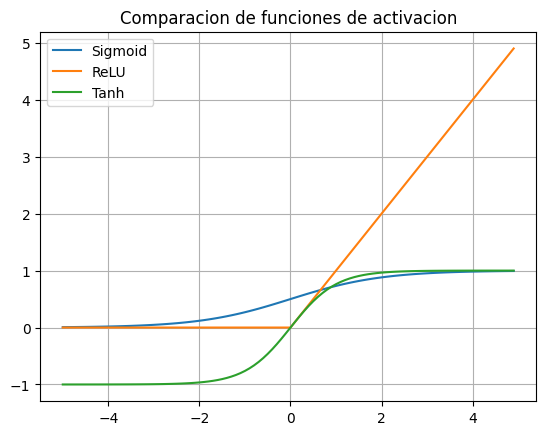

In [11]:
#visualizacion 
import matplotlib.pyplot as plt 

#generando valores numericos entre el rango de -50 al 50
x_vals = [i * 0.1 for i in range(-50,50)]

#introduccion de valores numericos entre las funciones de activacion
sigmoid_vals = [sigmoid(x) for x in x_vals]
relu_vals = [relu(x) for x in x_vals]
tanh_vals = [tanh(x) for x in x_vals]

#generando la grafica 
plt.plot(x_vals, sigmoid_vals, label="Sigmoid")
plt.plot(x_vals, relu_vals, label="ReLU")
plt.plot(x_vals, tanh_vals, label="Tanh")

plt.legend()
plt.title("Comparacion de funciones de activacion")
plt.grid()